<a href="https://colab.research.google.com/github/psycholinguistics-proj/proj/blob/main/D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Run these first, then skip to Part 2: Main Analysis
`Ctrl` + `Enter` to run the cell and stay in that cell
`Shift` + `Enter` to run the cell and move to the next cell

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore


In [ ]:
# Load the excel file from Drive
df = pd.read_excel('/content/drive/MyDrive/NLP/KLP_DB_final.xlsx', sheet_name='KLP_DB_final')

# Filter to words only
df_words = df[df['Lexicality'] == 1].copy()

# Log transform frequency
df_words['LogFreq'] = np.log(df_words['Freq'].replace('NA', np.nan).astype(float))


In [ ]:
# Filtering the data to the correct sample
key_vars = ['MRT', 'MHIT', 'LogFreq', 'syltkn1', 'syltkn2', 'syllbdy1', 'syllbdy2', 'rhym1', 'rhym2']
df_words = df_words.dropna(subset=key_vars)
print(f'Full word sample: {len(df_words)} words')

# Restricted sample matching original paper (syllable freq 15-50 only on freq range, not syll freq)
df_restricted = df_words[(df_words['Freq'] >= 15) & (df_words['Freq'] <= 50)].copy()
print(f'Restricted sample (Freq 15-50): {len(df_restricted)} words')


Full word sample: 4565 words
Restricted sample (Freq 15-50): 1778 words


# 1. Data Exploration (skip this)

In [ ]:
print(df_words.shape)
print(df_words.dtypes)

(4565, 27)
Lexicality      int64
stim_num        int64
Stim           object
MRT           float64
MHIT          float64
POS            object
NMeaning        int64
Nsyll           int64
NJamo2          int64
Freq          float64
lttr1          object
lttr2          object
lttr3          object
lttr4          object
lttr5          object
lttr6          object
syll1          object
syll2          object
syllbdy1        int64
syllbdy2        int64
rhym1           int64
rhym2           int64
syltyp1         int64
syltyp2         int64
syltkn2         int64
syltkn1         int64
LogFreq       float64
dtype: object


### Observations (see below)
* Massive spike at 100 for MHIT. Visually dramatic ceiling effect. MHIT modeles need to be run on sub-ceiling subset (MHIT < 100) as well as full sample and compared.
* Freq is extremely right-skewed. Huge spike at 0 with long tail. Log-trasforming Freq was applied because of this.
* syltkn1 and syltkn2 are both right-skewed with spiky distributions. Reflects how many words share the same first or second syllable, so token frequencies cluster at the same values. syltkn1 shows more extreme high-frequency values (tail extends more than syltkn2's tail), suggesting first-syllable competition is more intense than second-syllable comeptition. Considering log-transforming both for the regression.
* syllbdy1 and syllbdy2 have relatively flat distributions across a wide range. Maybe this means antibody frequency varies a lot across words. Either way, kind of unusual.
* NMeaning has enormous spike at 1, then rapidly declining. Why we need to separate between NMeaning=1, NMeaning>1

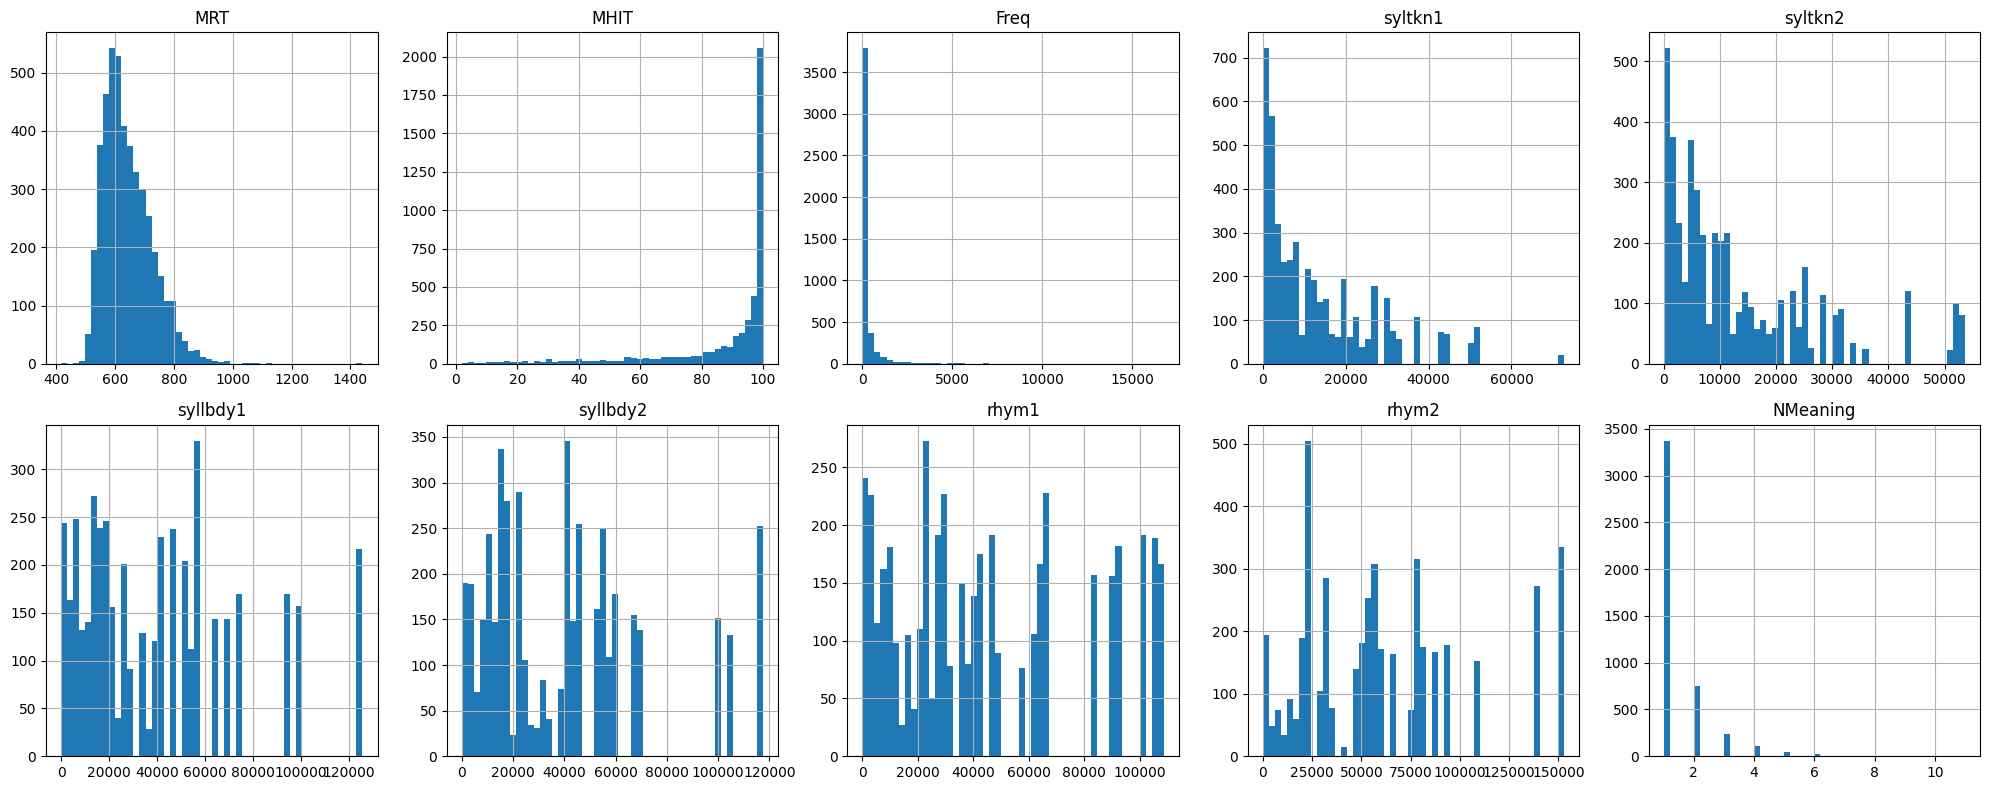

In [ ]:
# Plot variables' distributions
vars_of_interest = ['MRT', 'MHIT', 'Freq', 'syltkn1', 'syltkn2', 'syllbdy1', 'syllbdy2', 'rhym1', 'rhym2', 'NMeaning']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, var in zip(axes.flatten(), vars_of_interest):
  df_words[var].dropna().hist(ax=ax, bins=50, edgecolor='none')
  ax.set_title(var)
  ax.set_xlabel('')
plt.tight_layout()
plt.show()

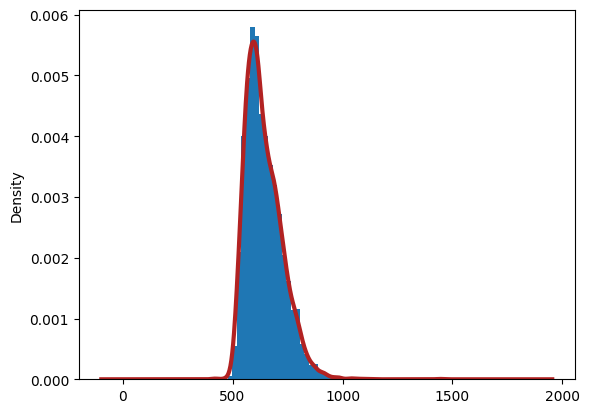

In [ ]:
# Check MRT
df_words.MRT.plot(kind="hist", bins=50, density=True)
df_words.MRT.plot(kind="kde", linewidth=3, color="firebrick")
plt.show()

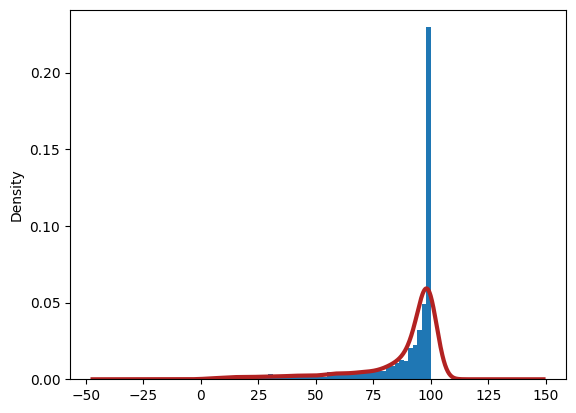

In [ ]:
# Check MHIT
df_words.MHIT.plot(kind="hist", bins=50, density=True)
df_words.MHIT.plot(kind="kde", linewidth=3, color="firebrick")
plt.show()

In [ ]:
# Use IQR to check for outliers
for var in ['MRT', 'syltkn1', 'syltkn2']:
  Q1 = df_words[var].quantile(0.25)
  Q3 = df_words[var].quantile(0.75)
  IQR = Q3 - Q1
  outliers = df_words[(df_words[var] < Q1 - 3 * IQR) |
                      (df_words[var] > Q3 + 3 * IQR)]
  print(f'{var}: {len(outliers)} outliers (3xIQR)')
  print(outliers[['Stim', var]].head() if len(outliers) else '-')

MRT: 6 outliers (3xIQR)
     Stim     MRT
1569   법열  1081.0
2693   염낭  1040.0
2839   울안  1441.0
3525   중석  1055.0
3745   책동  1113.0
syltkn1: 0 outliers (3xIQR)
-
syltkn2: 0 outliers (3xIQR)
-


### Observations  (see below)

* Will need to control for LogFreq (strong MRT vs. LogFreq correlation) to see syltkn1 vs MRT flipping to positive
* Collinearity warnings for: `syltkn1 vs. syllbdy1,` `syltkn2 vs. syllbdy2`, `syltkn2 vs rhym2`
(This explains why separate regressions were done in the original paper).
* NMeaning correlates with everythig but predicts neither MRT (-0.01) nor MHIT
(0.02)

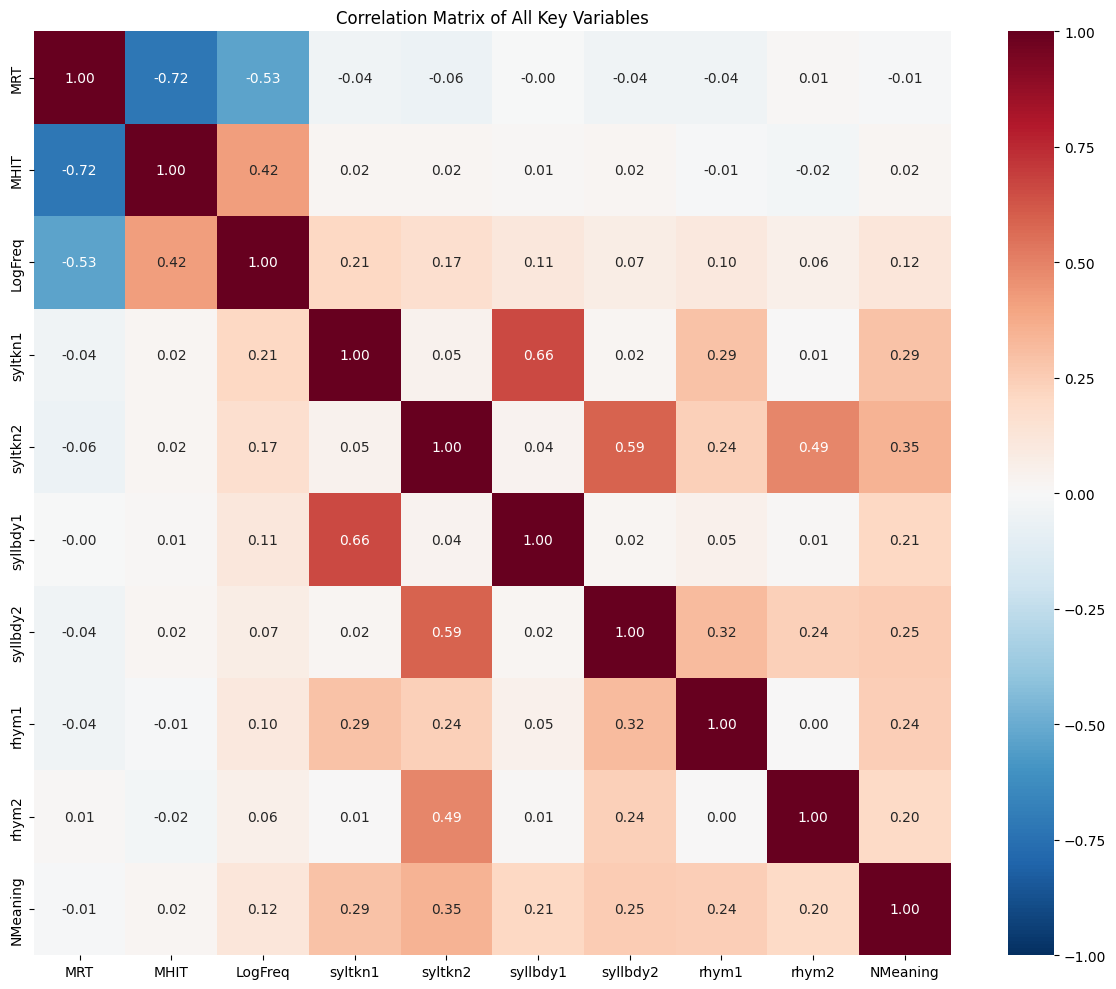

In [ ]:
# Full correlation matrix
corr_vars = ['MRT', 'MHIT', 'LogFreq', 'syltkn1', 'syltkn2', 'syllbdy1', 'syllbdy2', 'rhym1', 'rhym2', 'NMeaning']

corr_matrix = df_words[corr_vars].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1)
plt.title('Correlation Matrix of All Key Variables')
plt.tight_layout()
plt.show()

### Observations (see below)
* LogFreq -> MRT: approximately linear across main range of data. Makes linear regression term for LogFreq reasonable.
* syltkn1 -> MRT: almost completely flat but again, need to control for LogFreq.
* syltkn2 -> MRT: same as above

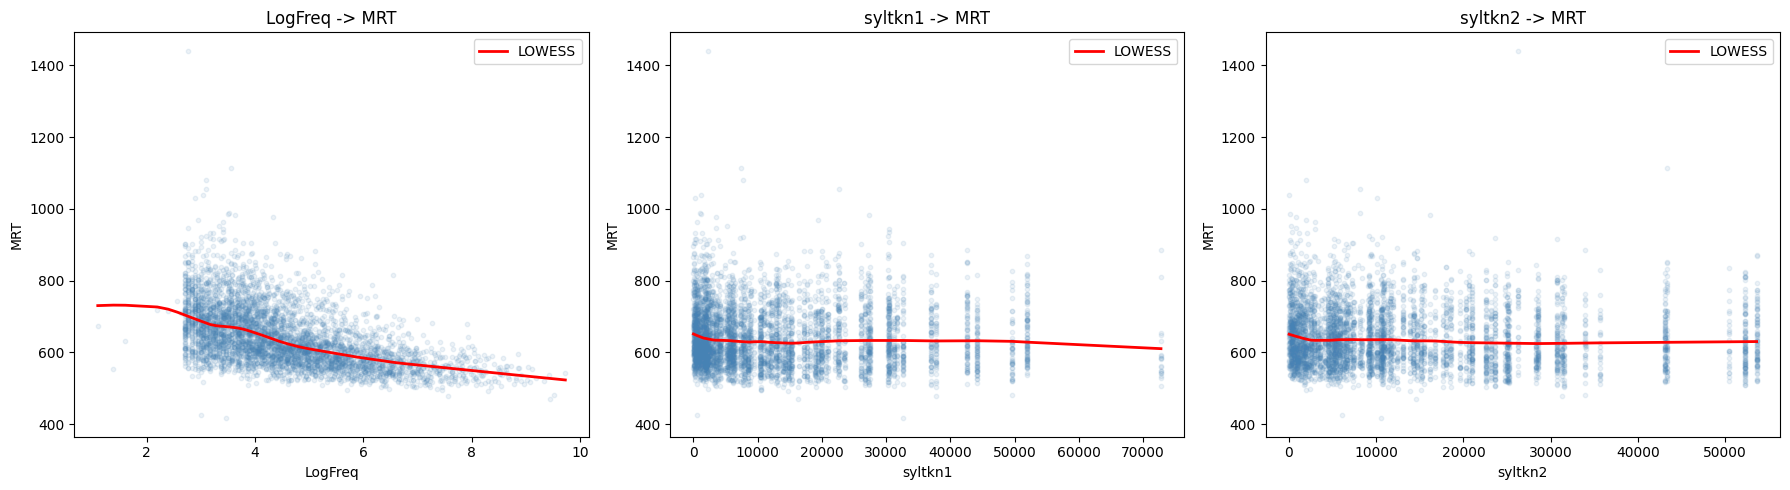

In [ ]:
# Scatter plots of key relationships with LOWESS smoother
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, ['LogFreq', 'syltkn1', 'syltkn2']):
  ax.scatter(df_words[var], df_words['MRT'], alpha=0.1, s=10, color='steelblue')

  clean = df_words[[var, 'MRT']].dropna()
  smoothed = lowess(clean['MRT'], clean[var], frac=0.3)
  ax.plot(smoothed[:,0], smoothed[:,1], color='red', linewidth=2, label='LOWESS')
  ax.set_xlabel(var)
  ax.set_ylabel('MRT')
  ax.set_title(f'{var} -> MRT')
  ax.legend()

plt.tight_layout()
plt.show()

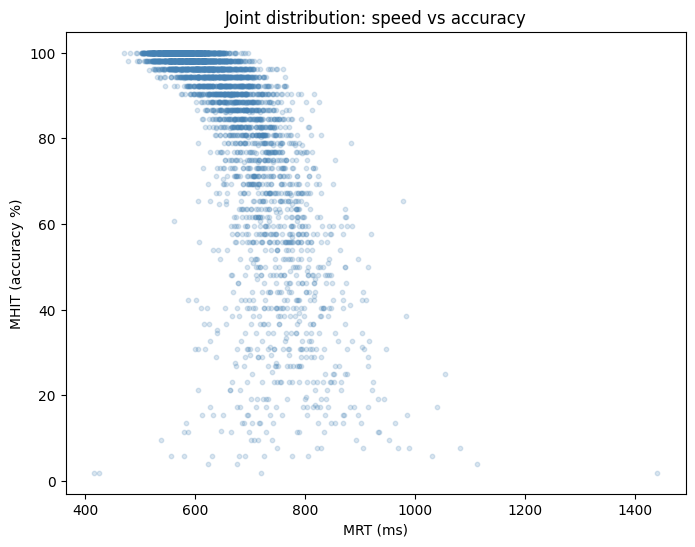

In [ ]:
# Joint distribution of MRT and MHIT
plt.figure(figsize=(8,6))
plt.scatter(df_words['MRT'], df_words['MHIT'], alpha=0.2, s=10, color='steelblue')
plt.xlabel('MRT (ms)')
plt.ylabel('MHIT (accuracy %)')
plt.title('Joint distribution: speed vs accuracy')

plt.show()

### Observations (see below)
VIF evidence says that the values, all well below 5, can be included together. However, we eshould still separate syltkn2 from sub-syllabic variables (syllbdy2, rhym2) for the clarity of interpretation.

In [ ]:
# Check VIF to identify multicollinearity
df_clean = df_words[['LogFreq', 'syltkn1', 'syltkn2', 'syllbdy2', 'rhym2']].dropna()
X = sm.add_constant(df_clean)

vif_data = pd.DataFrame()
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

   variable        VIF
0     const  15.442808
1   LogFreq   1.073779
2   syltkn1   1.044719
3   syltkn2   1.964065
4  syllbdy2   1.549610
5     rhym2   1.321765


In [ ]:
# Descriptive statistics table
desc_vars = ['MRT', 'MHIT', 'LogFreq', 'syltkn1', 'syltkn2', 'syllbdy1', 'syllbdy2', 'rhym1', 'rhym2']

desc = df_words[desc_vars].describe().T[['mean','std','min','max']]
desc.columns = ['Mean', 'SD', 'Min', 'Max']
desc = desc.round(2)
print(desc)

              Mean        SD     Min        Max
MRT         642.46     82.52  416.00    1441.00
MHIT         86.94     20.31    1.92     100.00
LogFreq       4.53      1.33    1.10       9.73
syltkn1   13393.00  13713.79   15.00   72768.00
syltkn2   13327.44  13395.43   15.00   53611.00
syllbdy1  40693.27  32523.98   28.00  125538.00
syllbdy2  40628.14  31770.70   27.00  117527.00
rhym1     44934.99  33820.64   15.00  108696.00
rhym2     62237.25  43033.78   15.00  153031.00


In [ ]:
# Correlation matrix
corr_table = df_words[desc_vars].corr().round(3)
print(corr_table)

            MRT   MHIT  LogFreq  syltkn1  syltkn2  syllbdy1  syllbdy2  rhym1  \
MRT       1.000 -0.724   -0.534   -0.042   -0.059    -0.004    -0.043 -0.042   
MHIT     -0.724  1.000    0.418    0.022    0.023     0.008     0.016 -0.015   
LogFreq  -0.534  0.418    1.000    0.206    0.166     0.110     0.071  0.105   
syltkn1  -0.042  0.022    0.206    1.000    0.045     0.658     0.020  0.293   
syltkn2  -0.059  0.023    0.166    0.045    1.000     0.038     0.592  0.238   
syllbdy1 -0.004  0.008    0.110    0.658    0.038     1.000     0.021  0.052   
syllbdy2 -0.043  0.016    0.071    0.020    0.592     0.021     1.000  0.320   
rhym1    -0.042 -0.015    0.105    0.293    0.238     0.052     0.320  1.000   
rhym2     0.009 -0.025    0.061    0.006    0.488     0.015     0.235  0.001   

          rhym2  
MRT       0.009  
MHIT     -0.025  
LogFreq   0.061  
syltkn1   0.006  
syltkn2   0.488  
syllbdy1  0.015  
syllbdy2  0.235  
rhym1     0.001  
rhym2     1.000  


# 2. Main Analysis (Draft 1)

### Observations (see below)
* Everything was put in simultaneously, but we still need to do hierarchical regression (variables need to be entered in steps so we can report ΔR² at each step - this is necessary to tell us how much additional variance `syltkn2` explains beyond LogFreq and `syltkn1` combined)
* This is only like a pilot analysis so we can see direction and rough magnitude of the effects.
* `syltkn1` effect > `syltkn2` effect (5.8 ms vs 2.5 ms - see coefficients). This is consistent with the serial processing account - the first syllable is processed first and drives most of the lexical competition. Alvarez et al. (2000) already predicted this for Spanish.
* Skew -> residuals (difference between what the regression model predicted and what actually happened aka `actual MRT - predicted MRT`) are not symmetrical. More large positive residudals
* Kurtosis -> residual distribution shows that there are more extreme values than expected
* `syltkn1` - 5.8 ms vs original paper's ~10.8 ms per SD because this one used the full word sample rather than the restricted low-frequency subset the paper used.
* 2.5 ms for `syltkn2` means that the second syllable contributes to lexical competition (but the effect is smaller than the first syllable effect)

In [ ]:
# Partial regression plots
df_clean = df_words[['MRT', 'LogFreq', 'syltkn1', 'syltkn2']].dropna()
X = sm.add_constant(df_clean[['LogFreq', 'syltkn1', 'syltkn2']])
y = df_clean['MRT']
model = sm.OLS(y, X).fit()
print("The model before predictors were standardized")
print(model.summary())

# fig = sm.graphics.plot_partregress_grid(model)
# fig.suptitle('Partial regression plots')
# plt.tight_layout()
# plt.show()


df_clean['LogFreq_z'] = zscore(df_clean['LogFreq'])
df_clean['syltkn1_z'] = zscore(df_clean['syltkn1'])
df_clean['syltkn2_z'] = zscore(df_clean['syltkn2'])

X_std = sm.add_constant(df_clean[['LogFreq_z', 'syltkn1_z', 'syltkn2_z']])
model_std = sm.OLS(df_clean['MRT'], X_std).fit()
print('***********************************************************************')
print("The model AFTER predictors were standardized")
print(model_std.summary())


The model before predictors were standardized
                            OLS Regression Results                            
Dep. Variable:                    MRT   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     622.0
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:20:44   Log-Likelihood:                -25840.
No. Observations:                4565   AIC:                         5.169e+04
Df Residuals:                    4561   BIC:                         5.171e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

### Observations (see below)
* Full sample - both `syltkn1` and `syltkn2` are significant. ΔR² at Step 3 is small (0.0009).
* Restricted sample - p = .5151 means that `syltkn2` is not significant (when restricted to low-frequency words)

In [ ]:
# Main analysis: MRT models (hierarchical)

def run_hierarchical(df, dv='MRT'):
  df_c = df[['MRT', 'MHIT', 'LogFreq', 'syltkn1', 'syltkn2']].dropna()
  y = df_c[dv]

  # Step 1: control only
  m1 = sm.OLS(y, sm.add_constant(df_c[['LogFreq']])).fit()

  # Step 2: add syltkn1 (paper replication)
  m2 = sm.OLS(y, sm.add_constant(df_c[['LogFreq', 'syltkn1']])).fit()

  # Step 3: add syltkn2
  m3 = sm.OLS(y, sm.add_constant(df_c[['LogFreq', 'syltkn1', 'syltkn2']])).fit()

  print(f'\n--- {dv} Hierarchical Regression ---')
  print(f'Step 1: R²={m1.rsquared:.3f}')
  print(f'  LogFreq: β={m1.params["LogFreq"]:.4f}, p={m1.pvalues["LogFreq"]:.4f}')

  print(f'\nStep 2: R²={m2.rsquared:.3f}, ΔR²={m2.rsquared-m1.rsquared:.4f}')
  print(f'  LogFreq: β={m2.params["LogFreq"]:.4f}, p={m2.pvalues["LogFreq"]:.4f}')
  print(f'  syltkn1: β={m2.params["syltkn1"]:.6f}, p={m2.pvalues["syltkn1"]:.4f}')

  print(f'\nStep 3: R²={m3.rsquared:.3f}, ΔR²={m3.rsquared-m2.rsquared:.4f}')
  print(f'  LogFreq: β={m3.params["LogFreq"]:.4f}, p={m3.pvalues["LogFreq"]:.4f}')
  print(f'  syltkn1: β={m3.params["syltkn1"]:.6f}, p={m3.pvalues["syltkn1"]:.4f}')
  print(f'  syltkn2: β={m3.params["syltkn2"]:.6f}, p={m3.pvalues["syltkn2"]:.4f}')

  return m1, m2, m3

# Run on full sample
print('========= FULL SAMPLE =========')
m1, m2, m3 = run_hierarchical(df_words, dv='MRT')


# Run on restricted sample
print('\n========= RESTRICTED SAMPLE =========')
r1, r2, r3 = run_hierarchical(df_restricted, dv='MRT')


========= FULL SAMPLE =========

--- MRT Hierarchical Regression ---
Step 1: R²=0.285
  LogFreq: β=-33.1415, p=0.0000

Step 2: R²=0.289, ΔR²=0.0048
  LogFreq: β=-34.0503, p=0.0000
  syltkn1: β=0.000427, p=0.0000

Step 3: R²=0.290, ΔR²=0.0009
  LogFreq: β=-34.3585, p=0.0000
  syltkn1: β=0.000425, p=0.0000
  syltkn2: β=0.000186, p=0.0168

========= RESTRICTED SAMPLE =========

--- MRT Hierarchical Regression ---
Step 1: R²=0.019
  LogFreq: β=-32.1969, p=0.0000

Step 2: R²=0.025, ΔR²=0.0055
  LogFreq: β=-32.8002, p=0.0000
  syltkn1: β=0.000494, p=0.0016

Step 3: R²=0.025, ΔR²=0.0002
  LogFreq: β=-32.7859, p=0.0000
  syltkn1: β=0.000491, p=0.0016
  syltkn2: β=0.000103, p=0.5151


### Observations (see below)
* negative coefficients mean that higher syllable token is associated with lower accuracy. (Makes sense: more competition -> more errors)
* Suggests speed and accuracy are being affected by the same mechanism, *not dissociating*.


In [ ]:
# Parallel MHIT models
print('========= FULL SAMPLE =========')
mhit1, mhit2, mhit3 = run_hierarchical(df_words, dv='MHIT')

# Sub-ceiling (MHIT < 100)
df_subceil = df_words[df_words['MHIT'] < 100].copy()
print(f'\nSub-ceiling sample: {len(df_subceil)} words')
print('========= SUB-CEILING SAMPLE - MHIT =========')
mhit_s1, mhit_s2, mhit_s3 = run_hierarchical(df_subceil, dv='MHIT')

========= FULL SAMPLE =========

--- MHIT Hierarchical Regression ---
Step 1: R²=0.174
  LogFreq: β=6.3846, p=0.0000

Step 2: R²=0.179, ΔR²=0.0044
  LogFreq: β=6.5970, p=0.0000
  syltkn1: β=-0.000100, p=0.0000

Step 3: R²=0.181, ΔR²=0.0021
  LogFreq: β=6.7142, p=0.0000
  syltkn1: β=-0.000099, p=0.0000
  syltkn2: β=-0.000071, p=0.0006

Sub-ceiling sample: 3356 words
========= SUB-CEILING SAMPLE - MHIT =========

--- MHIT Hierarchical Regression ---
Step 1: R²=0.146
  LogFreq: β=7.3533, p=0.0000

Step 2: R²=0.150, ΔR²=0.0043
  LogFreq: β=7.5724, p=0.0000
  syltkn1: β=-0.000108, p=0.0000

Step 3: R²=0.152, ΔR²=0.0021
  LogFreq: β=7.6774, p=0.0000
  syltkn1: β=-0.000107, p=0.0000
  syltkn2: β=-0.000076, p=0.0043


In [ ]:
# Get SDs
sd_syltkn1 = df_words['syltkn1'].std()
sd_syltkn2 = df_words['syltkn2'].std()
sd_logfreq = df_words['LogFreq'].std()


# Access coefficients directly from the model object
print('=== MRT Step 3 — effect sizes ===')
print(f'LogFreq:  {m3.params["LogFreq"] * sd_logfreq:.2f} ms per SD')
print(f'syltkn1:  {m3.params["syltkn1"] * sd_syltkn1:.2f} ms per SD')
print(f'syltkn2:  {m3.params["syltkn2"] * sd_syltkn2:.2f} ms per SD')

print()
print('=== MHIT sub-ceiling Step 3 — effect sizes ===')
print(f'LogFreq:  {mhit_s3.params["LogFreq"] * sd_logfreq:.2f} % per SD')
print(f'syltkn1:  {mhit_s3.params["syltkn1"] * sd_syltkn1:.2f} % per SD')
print(f'syltkn2:  {mhit_s3.params["syltkn2"] * sd_syltkn2:.2f} % per SD')

=== MRT Step 3 — effect sizes ===
LogFreq:  -45.64 ms per SD
syltkn1:  5.83 ms per SD
syltkn2:  2.50 ms per SD

=== MHIT sub-ceiling Step 3 — effect sizes ===
LogFreq:  10.20 % per SD
syltkn1:  -1.47 % per SD
syltkn2:  -1.02 % per SD


### Overall Findings from Phase 1
1. Replication of effect of first-syllable token freq on MRT replicates in both the full sample and restricted low-freq sample. Consistent with the original paper.
2. Second-syllable token freq predicts MRT in the full sample (β = +0.000186, p = .017, which was standardized to +2.50ms per standard deviation). Suggests second-syllable competition contributes additional inhibition. Consistent with partial parallel processing?
**IMPORTANT NOTE**: effect does not replicate in restricted low-freq sample (p = .515)
3. Both `syltkn1` and `syltkn2` significantly predict MHIT in the negative direction in both the full sample and sub-ceiling (MHIT < 100) sample. Speed and accuracy are not dissociating (they are affected by the same mechanism)
4. `Freq` x `syltkn2` is not significant. The second-syllable effect does nto vary as a function of word frequency.

In [51]:
# Create frequency quartiles
# Only use words that have Freq data (not NA)
df_q = df_words[['MRT', 'LogFreq', 'syltkn1', 'syltkn2', 'Freq']].dropna().copy()

df_q['FreqQuartile'] = pd.qcut(df_q['Freq'],
                                q=4,
                                labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

# Check how many words per quartile
print('Words per quartile:')
print(df_q['FreqQuartile'].value_counts().sort_index())
print()

# Run regression within each quartile
sd_syltkn2 = df_words['syltkn2'].std()
results = []
print(f'{"Quartile":<15} {"n":>5} {"syltkn2 β":>12} {"SE":>10} {"t":>8} {"p":>8} {"sig":>6} {"   | effect (ms per SD)":>6}')
print('-' * 95)

for q in ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']:
    subset = df_q[df_q['FreqQuartile'] == q]
    X = sm.add_constant(subset[['LogFreq', 'syltkn1', 'syltkn2']])
    m = sm.OLS(subset['MRT'], X).fit()

    b = m.params['syltkn2']
    se = m.bse['syltkn2']
    t = m.tvalues['syltkn2']
    p = m.pvalues['syltkn2']
    ci_low = m.conf_int().loc['syltkn2', 0]
    ci_high = m.conf_int().loc['syltkn2', 1]
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
    effect = b * sd_syltkn2

    print(f'{q:<15} {len(subset):>5} {b:>12.6f} {se:>10.6f} {t:>8.3f} {p:>8.4f}  {sig:>7}  | {effect:>8.2f}')

    results.append({
        'quartile': q,
        'n': len(subset),
        'beta': b,
        'se': se,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'p': p,
        'sig': sig
    })

print()
print('Freq range per quartile:')
for q in ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']:
    subset = df_q[df_q['FreqQuartile'] == q]
    print(f'{q}: Freq {subset["Freq"].min():.0f} – {subset["Freq"].max():.0f}')

Words per quartile:
FreqQuartile
Q1 (lowest)     1176
Q2              1120
Q3              1129
Q4 (highest)    1140
Name: count, dtype: int64

Quartile            n    syltkn2 β         SE        t        p    sig    | effect (ms per SD)
-----------------------------------------------------------------------------------------------
Q1 (lowest)      1176    -0.000058   0.000198   -0.294   0.7690     n.s.  |    -0.78
Q2               1120     0.000551   0.000174    3.169   0.0016       **  |     7.38
Q3               1129     0.000162   0.000141    1.143   0.2531     n.s.  |     2.17
Q4 (highest)     1140     0.000070   0.000098    0.715   0.4749     n.s.  |     0.94

Freq range per quartile:
Q1 (lowest): Freq 3 – 33
Q2: Freq 34 – 73
Q3: Freq 74 – 209
Q4 (highest): Freq 210 – 16768


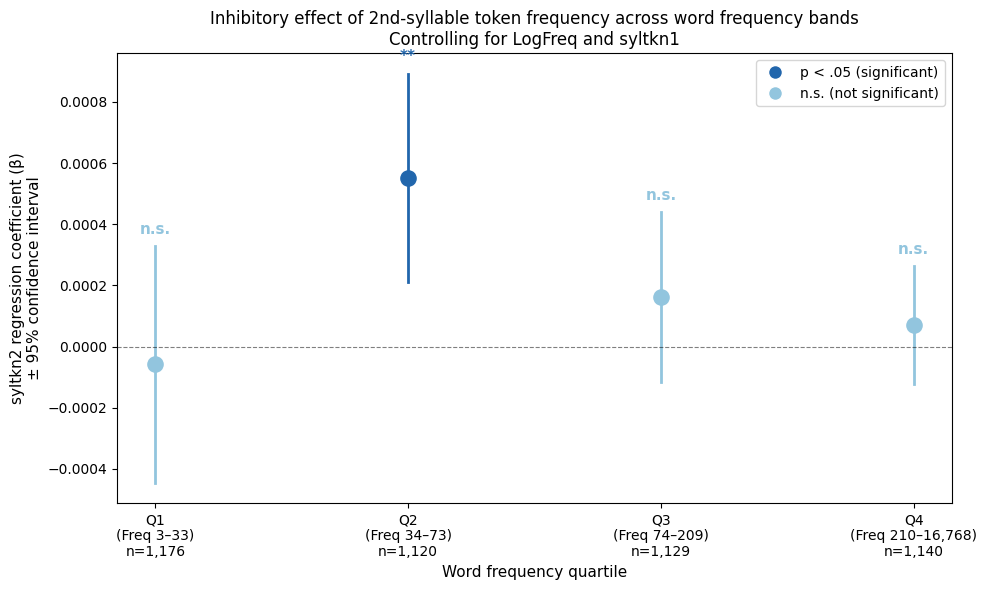

In [ ]:
quartiles = ['Q1\n(Freq 3–33)\nn=1,176',
             'Q2\n(Freq 34–73)\nn=1,120',
             'Q3\n(Freq 74–209)\nn=1,129',
             'Q4\n(Freq 210–16,768)\nn=1,140']

betas = [r['beta'] for r in results]
ci_lows = [r['ci_low'] for r in results]
ci_highs = [r['ci_high'] for r in results]
pvals = [r['p'] for r in results]
sigs = [r['sig'] for r in results]

# Colors: significant = darker, n.s. = lighter
colors = ['#2166ac' if p < .05 else '#92c5de' for p in pvals]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(quartiles))

# Plot confidence interval lines first
for i in range(len(quartiles)):
    ax.plot([x[i], x[i]], [ci_lows[i], ci_highs[i]],
            color=colors[i], linewidth=2, zorder=2)

# Plot beta dots
for i in range(len(quartiles)):
    ax.scatter(x[i], betas[i],
               color=colors[i], s=120, zorder=3,
               label='p < .05' if pvals[i] < .05 else 'n.s.')

# Zero reference line
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Significance labels above each point
for i in range(len(quartiles)):
    y_pos = ci_highs[i] + 0.00003
    ax.text(x[i], y_pos, sigs[i],
            ha='center', va='bottom', fontsize=11,
            color=colors[i], fontweight='bold')

# Axis labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(quartiles, fontsize=10)
ax.set_ylabel('syltkn2 regression coefficient (β)\n± 95% confidence interval', fontsize=11)
ax.set_xlabel('Word frequency quartile', fontsize=11)
ax.set_title('Inhibitory effect of 2nd-syllable token frequency across word frequency bands\n'
             'Controlling for LogFreq and syltkn1', fontsize=12)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2166ac',
           markersize=10, label='p < .05 (significant)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#92c5de',
           markersize=10, label='n.s. (not significant)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('quartile_syltkn2_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Extras

In [ ]:
# Sub-syllabic analysis
def run_subsyllabic(df, dv='MRT'):
    df_c = df[['MRT','MHIT','LogFreq','syllbdy1','rhym1','syllbdy2','rhym2']].dropna()
    y = df_c[dv]

    # Original paper's Analysis 2 (first syllable)
    m_orig = sm.OLS(y, sm.add_constant(df_c[['LogFreq','syllbdy1','rhym1']])).fit()

    # Our extension (second syllable)
    m_ext = sm.OLS(y, sm.add_constant(df_c[['LogFreq','syllbdy2','rhym2']])).fit()

    print(f'\n--- Sub-syllabic Analysis ({dv}) ---')
    print(f'First syllable model (replication):')
    print(f'  R²={m_orig.rsquared:.3f}')
    print(f'  syllbdy1: β={m_orig.params["syllbdy1"]:.6f}, p={m_orig.pvalues["syllbdy1"]:.4f}')
    print(f'  rhym1:    β={m_orig.params["rhym1"]:.6f}, p={m_orig.pvalues["rhym1"]:.4f}')

    print(f'\nSecond syllable model (extension):')
    print(f'  R²={m_ext.rsquared:.3f}')
    print(f'  syllbdy2: β={m_ext.params["syllbdy2"]:.6f}, p={m_ext.pvalues["syllbdy2"]:.4f}')
    print(f'  rhym2:    β={m_ext.params["rhym2"]:.6f}, p={m_ext.pvalues["rhym2"]:.4f}')

    return m_orig, m_ext

run_subsyllabic(df_words, dv='MRT')


--- Sub-syllabic Analysis (MRT) ---
First syllable model (replication):
  R²=0.288
  syllbdy1: β=0.000138, p=0.0000
  rhym1:    β=0.000028, p=0.3647

Second syllable model (extension):
  R²=0.287
  syllbdy2: β=-0.000042, p=0.2150
  rhym2:    β=0.000088, p=0.0004


(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7dca54a82690>,
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7dca54a80a40>)

In [ ]:
# Frequency moderation interaction
df_int = df_words[['MRT','LogFreq','syltkn1','syltkn2']].dropna().copy()

# Mean-center before creating interaction term
df_int['LogFreq_c'] = df_int['LogFreq'] - df_int['LogFreq'].mean()
df_int['syltkn2_c'] = df_int['syltkn2'] - df_int['syltkn2'].mean()
df_int['syltkn1_c'] = df_int['syltkn1'] - df_int['syltkn1'].mean()
df_int['interaction'] = df_int['LogFreq_c'] * df_int['syltkn2_c']

X_int = sm.add_constant(df_int[['LogFreq_c','syltkn1_c','syltkn2_c','interaction']])
m_int = sm.OLS(df_int['MRT'], X_int).fit()

print('\n--- Frequency × syltkn2 Interaction ---')
print(f'R²={m_int.rsquared:.3f}')
for pred in ['LogFreq_c','syltkn1_c','syltkn2_c','interaction']:
    print(f'  {pred}: β={m_int.params[pred]:.6f}, p={m_int.pvalues[pred]:.4f}')


--- Frequency × syltkn2 Interaction ---
R²=0.291
  LogFreq_c: β=-34.499684, p=0.0000
  syltkn1_c: β=0.000423, p=0.0000
  syltkn2_c: β=0.000179, p=0.0222
  interaction: β=0.000062, p=0.2672


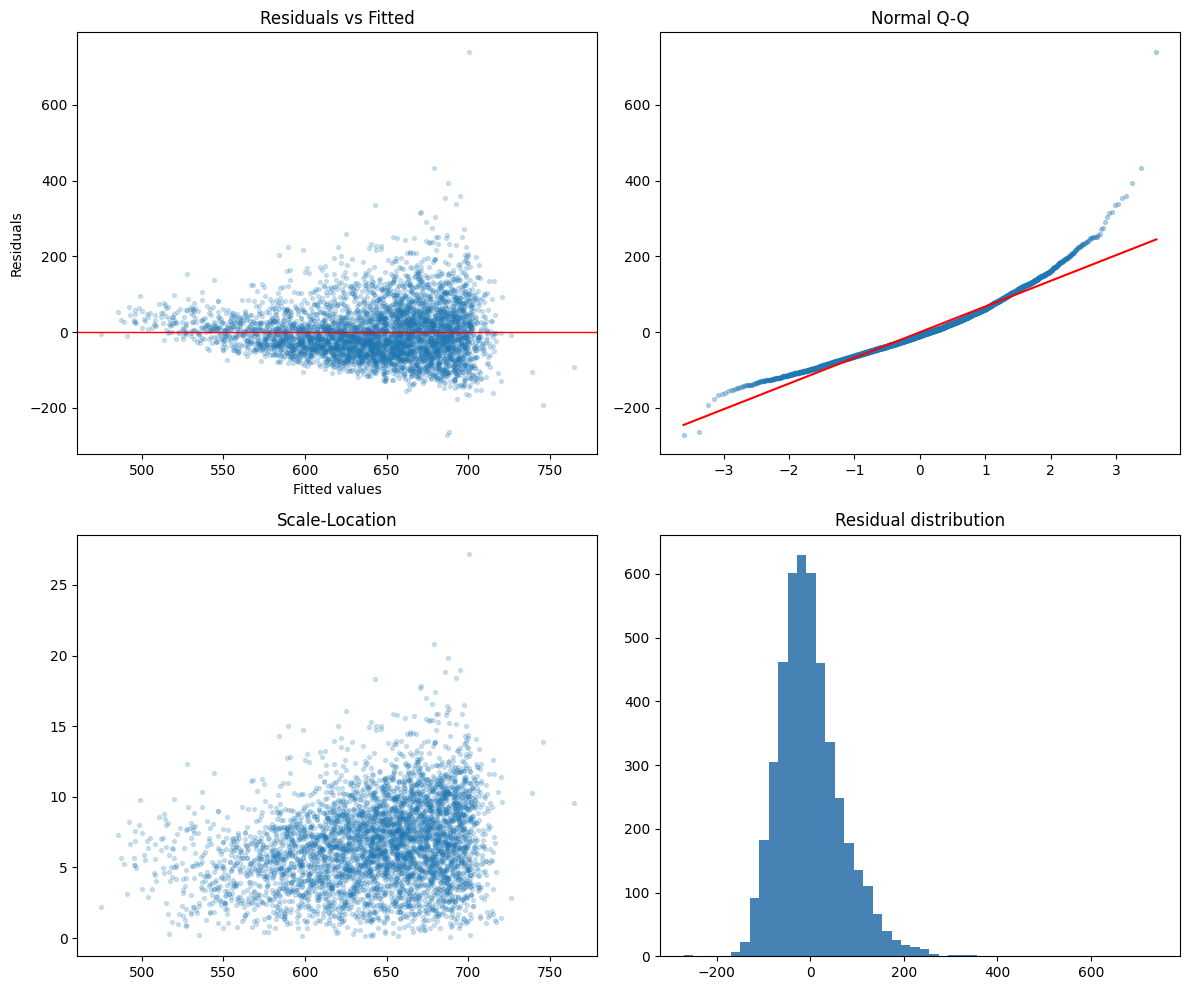


Most underpredicted (model said fast, actually slow):
     Stim     MRT    residual
2839   울안  1441.0  740.348666
3745   책동  1113.0  433.872239
1569   법열  1081.0  393.515331
3525   중석  1055.0  360.024904
2693   염낭  1040.0  354.064957
4451   홈통  1031.0  338.277461
2844   웃옷   978.0  335.146958
77     갑석   989.0  318.143941
596    길섶   985.0  314.605859
177    결격   984.0  304.295812

Most overpredicted (model said slow, actually fast):
     Stim    MRT    residual
936    동발  416.0 -270.812997
2487   앙등  426.0 -262.462445
4561   강남  553.0 -192.932518
872    당황  517.0 -175.992870
4479   환생  535.0 -165.348510
832    달인  534.0 -164.379173
1399   발각  556.0 -159.348364
2764   완결  508.0 -154.055024
2287   신곡  556.0 -151.950181
2040   선약  553.0 -151.862831


In [ ]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df_c = df_words[['MRT','LogFreq','syltkn1','syltkn2']].dropna()
y = df_c['MRT']
X = sm.add_constant(df_c[['LogFreq','syltkn1','syltkn2']])
model = sm.OLS(y, X).fit()

residuals = model.resid
fitted = model.fittedvalues

# 1. Residuals vs fitted
axes[0,0].scatter(fitted, residuals, alpha=0.2, s=8)
axes[0,0].axhline(0, color='red', linewidth=1)
axes[0,0].set_xlabel('Fitted values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuals)
axes[0,1].scatter(osm, osr, alpha=0.3, s=8)
axes[0,1].plot(osm, slope*np.array(osm)+intercept, color='red')
axes[0,1].set_title('Normal Q-Q')

# 3. Scale-location
axes[1,0].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.2, s=8)
axes[1,0].set_title('Scale-Location')

# 4. Residual histogram
axes[1,1].hist(residuals, bins=50, edgecolor='none', color='steelblue')
axes[1,1].set_title('Residual distribution')

plt.tight_layout()
plt.show()

# Worst predicted words
df_c['residual'] = residuals
df_c['Stim'] = df_words.loc[df_c.index, 'Stim']
print('\nMost underpredicted (model said fast, actually slow):')
print(df_c.nlargest(10,'residual')[['Stim','MRT','residual']])
print('\nMost overpredicted (model said slow, actually fast):')
print(df_c.nsmallest(10,'residual')[['Stim','MRT','residual']])

In [ ]:
from sklearn.model_selection import train_test_split

df_c = df_words[['MRT','LogFreq','syltkn1','syltkn2']].dropna()

# Run 5 times on random 80% subsamples
print('Robustness check — coefficients across 5 random 80% subsamples:')
print(f'{"Sample":<10} {"LogFreq":>10} {"syltkn1":>12} {"syltkn2":>12} {"R²":>8}')

for i in range(5):
    train, _ = train_test_split(df_c, test_size=0.2, random_state=i)
    X = sm.add_constant(train[['LogFreq','syltkn1','syltkn2']])
    m = sm.OLS(train['MRT'], X).fit()
    print(f'Run {i+1:<6} {m.params["LogFreq"]:>10.4f} {m.params["syltkn1"]:>12.6f} {m.params["syltkn2"]:>12.6f} {m.rsquared:>8.3f}')

Robustness check — coefficients across 5 random 80% subsamples:
Sample        LogFreq      syltkn1      syltkn2       R²
Run 1        -34.7547     0.000409     0.000185    0.305
Run 2        -34.4794     0.000443     0.000215    0.284
Run 3        -34.2408     0.000424     0.000135    0.292
Run 4        -34.7265     0.000396     0.000174    0.290
Run 5        -34.8092     0.000437     0.000168    0.294
